<a href="https://colab.research.google.com/github/SufiaAfrin/DIP_project/blob/main/Plant_leaf_disease_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Firstly, download Dataset**

In [17]:
!wget -q https://huggingface.co/datasets/mohanty/PlantVillage/resolve/main/data.zip -O plantvillage.zip

In [18]:
!ls -lh plantvillage.zip

-rw-r--r-- 1 root root 2.1G Feb  5  2026 plantvillage.zip


In [19]:
import zipfile
import os

with zipfile.ZipFile("plantvillage.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [20]:
import os

print(os.listdir("dataset/raw/color")[:20])

['Grape___Black_rot', 'Apple___Cedar_apple_rust', 'Soybean___healthy', 'Peach___healthy', 'Cherry_(including_sour)___healthy', 'Tomato___Tomato_mosaic_virus', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Pepper,_bell___Bacterial_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Apple___Black_rot', 'Apple___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Corn_(maize)___healthy', 'Peach___Bacterial_spot', 'Potato___Early_blight', 'Strawberry___healthy', 'Grape___Esca_(Black_Measles)', 'Corn_(maize)___Common_rust_', 'Orange___Haunglongbing_(Citrus_greening)']


In [21]:
import os
import shutil

source_healthy = "dataset/raw/color/Tomato___healthy"
source_early = "dataset/raw/color/Tomato___Early_blight"

healthy_path = "dataset/Healthy"
early_path = "dataset/Early_Blight"

shutil.copytree(source_healthy, healthy_path, dirs_exist_ok=True)
shutil.copytree(source_early, early_path, dirs_exist_ok=True)

print("Healthy images copied:", len(os.listdir(healthy_path)))
print("Early Blight images copied:", len(os.listdir(early_path)))

Healthy images copied: 1591
Early Blight images copied: 1000


In [22]:
import os

print("Healthy:", len(os.listdir("dataset/raw/color/Tomato___healthy")))
print("Early Blight:", len(os.listdir("dataset/raw/color/Tomato___Early_blight")))

Healthy: 1591
Early Blight: 1000


**Then Its all about Preprocessing**

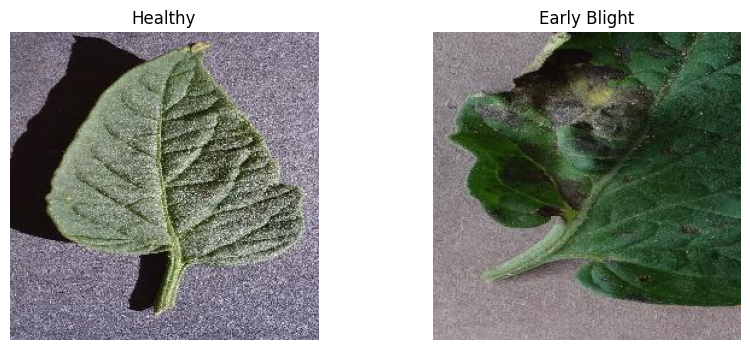

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import os

healthy_path = "dataset/Healthy"
early_path = "dataset/Early_Blight"

healthy_image = os.listdir(healthy_path)[0]
early_image = os.listdir(early_path)[0]

img1 = Image.open(os.path.join(healthy_path, healthy_image))
img2 = Image.open(os.path.join(early_path, early_image))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Healthy")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Early Blight")
plt.axis("off")

plt.show()

In [24]:
import numpy as np

# Convert the image to a NumPy array
img_array = np.array(img1)

# Normalize pixel values
img_normalized = img_array / 255.0

print("Image shape:", img_array.shape)
print("Minimum normalized value:", img_normalized.min())
print("Maximum normalized value:", img_normalized.max())

Image shape: (256, 256, 3)
Minimum normalized value: 0.0
Maximum normalized value: 1.0


In [25]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [26]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

DATASET_PATH = "dataset/raw/color"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    class_names=["Tomato___Early_blight", "Tomato___healthy"]
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    class_names=["Tomato___Early_blight", "Tomato___healthy"]
)

print("Classes:", train_ds.class_names)

Found 2591 files belonging to 2 classes.
Using 2073 files for training.
Found 2591 files belonging to 2 classes.
Using 518 files for validation.
Classes: ['Tomato___Early_blight', 'Tomato___healthy']


In [27]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

print("Data augmentation created successfully!")

Data augmentation created successfully!


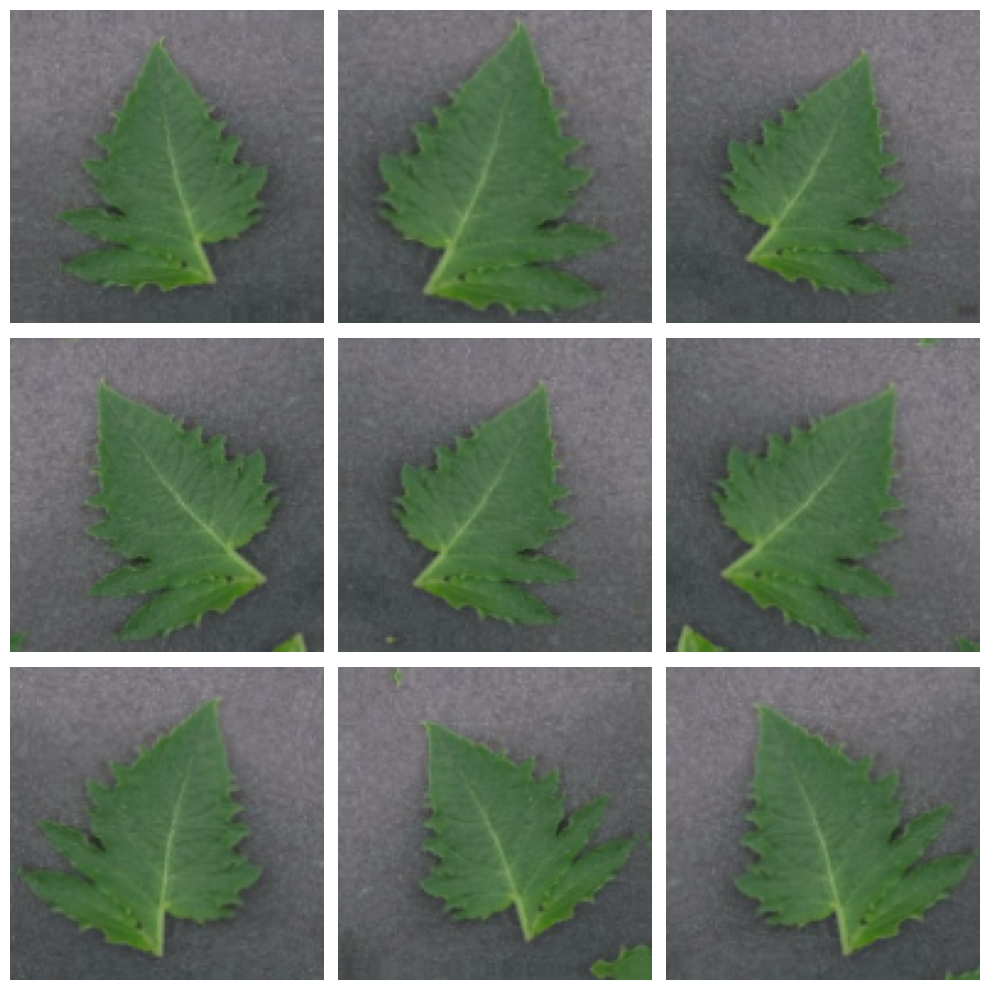

In [28]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    original_image = images[0]

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(original_image, 0),
            training=True
        )

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")

plt.tight_layout()
plt.show()

**separation datasets for Testing, Training and validation**

In [29]:
import tensorflow as tf

DATASET_PATH = "dataset"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = ["Early_Blight", "Healthy"]

# First split: 80% training, 20% temporary
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    class_names=CLASS_NAMES
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    class_names=CLASS_NAMES
)

# Split the temporary 20% into:
# 10% validation + 10% testing
temp_batches = tf.data.experimental.cardinality(temp_ds)

val_size = temp_batches // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

print("Classes:", train_ds.class_names)
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 2591 files belonging to 2 classes.
Using 2073 files for training.
Found 2591 files belonging to 2 classes.
Using 518 files for validation.
Classes: ['Early_Blight', 'Healthy']
Training batches: 65
Validation batches: 8
Testing batches: 9


Then trained the model

In [30]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Input + augmentation
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,

    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Binary output
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [32]:
import os
import tensorflow as tf

SAVE_DIR = "/content/Plant_Leaf_Disease_Project"
os.makedirs(SAVE_DIR, exist_ok=True)

checkpoint_path = os.path.join(
    SAVE_DIR,
    "best_tomato_leaf_model.keras"
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Callbacks are ready!")

Callbacks are ready!


**Training Cell**

In [33]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        model_checkpoint
    ]
)

Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5942 - loss: 38.5109
Epoch 1: val_loss improved from None to 0.31570, saving model to /content/Plant_Leaf_Disease_Project/best_tomato_leaf_model.keras

Epoch 1: finished saving model to /content/Plant_Leaf_Disease_Project/best_tomato_leaf_model.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.6725 - loss: 11.3890 - val_accuracy: 0.8789 - val_loss: 0.3157
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8640 - loss: 0.3460
Epoch 2: val_loss improved from 0.31570 to 0.17991, saving model to /content/Plant_Leaf_Disease_Project/best_tomato_leaf_model.keras

Epoch 2: finished saving model to /content/Plant_Leaf_Disease_Project/best_tomato_leaf_model.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8664 - loss: 0.3419 - val_accuracy: 0.9453 - val_loss: 0.1799
Epoch 3/15
63/65 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9004 - loss: 0.2588
Epoch 3: val_loss improved from 0.17991 to 0.154

In [34]:
import tensorflow as tf

best_model = tf.keras.models.load_model(
    "/content/Plant_Leaf_Disease_Project/best_tomato_leaf_model.keras"
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [35]:
test_loss, test_accuracy = best_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9618 - loss: 0.8183
Test Loss: 0.8182881474494934
Test Accuracy: 0.9618320465087891
Test Accuracy (%): 96.1832046508789


Number of samples: 262
Actual labels: [ 87 175]
Predicted labels: [ 83 179]

Confusion Matrix:
[[ 83   4]
 [  0 175]]

Classification Report:
              precision    recall  f1-score   support

Early_Blight       1.00      0.95      0.98        87
     Healthy       0.98      1.00      0.99       175

    accuracy                           0.98       262
   macro avg       0.99      0.98      0.98       262
weighted avg       0.99      0.98      0.98       262



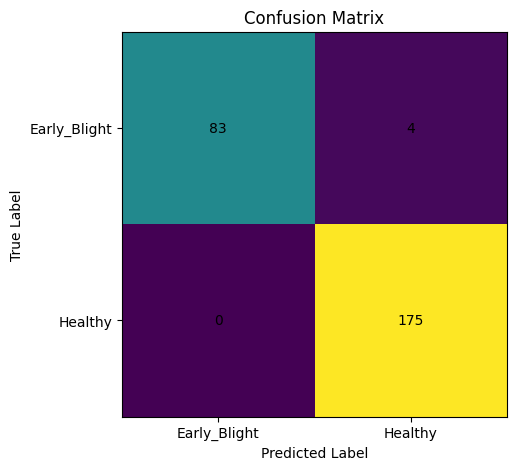

In [36]:

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Get class names from the training dataset
class_names = train_ds.class_names

# Get predictions and true labels together
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_prob.extend(probs.flatten())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

# Convert probabilities to labels
y_pred = (y_prob >= 0.5).astype(int)

print("Number of samples:", len(y_true))
print("Actual labels:", np.bincount(y_true))
print("Predicted labels:", np.bincount(y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [37]:
import numpy as np

# Get actual labels from training dataset
train_labels = np.concatenate([
    y.numpy().astype(int).flatten()
    for x, y in train_ds
])

# Get actual labels from validation dataset
val_labels = np.concatenate([
    y.numpy().astype(int).flatten()
    for x, y in val_ds
])

print("Training class distribution:")
print(np.bincount(train_labels))

print("\nValidation class distribution:")
print(np.bincount(val_labels))

print("\nTest class distribution:")
print(np.bincount(y_true.astype(int)))

Training class distribution:
[ 810 1263]

Validation class distribution:
[ 99 157]

Test class distribution:
[ 87 175]


In [38]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class weights:")
print(class_weight_dict)

Class weights:
{0: np.float64(1.2796296296296297), 1: np.float64(0.8206650831353919)}


In [39]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Callbacks
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Plant_Leaf_Disease_Project/best_weighted_tomato_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Train with class weights
weighted_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/15
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9750 - loss: 0.0881
Epoch 1: val_loss improved from None to 0.93771, saving model to /content/drive/MyDrive/Plant_Leaf_Disease_Project/best_weighted_tomato_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Plant_Leaf_Disease_Project/best_weighted_tomato_model.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9706 - loss: 0.0949 - val_accuracy: 0.9570 - val_loss: 0.9377 - learning_rate: 0.0010
Epoch 2/15
63/65 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9798 - loss: 0.0716
Epoch 2: val_loss improved from 0.93771 to 0.03857, saving model to /content/drive/MyDrive/Plant_Leaf_Disease_Project/best_weighted_tomato_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Plant_Leaf_Disease_Project/best_weighted_tomato_model.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9677 - loss: 0.1079 - val_accuracy: 0.9922 - val_loss: 0.0386 - learning_rate: 0.0010
Epoch 3/15
63/6

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

print("Threshold | Accuracy | Early_Blight Recall | Healthy Recall | Early_Blight F1")
print("-" * 75)

for threshold in thresholds:
    predictions = (y_prob.flatten() >= threshold).astype(int)

    accuracy = accuracy_score(y_true, predictions)
    early_recall = recall_score(y_true, predictions, pos_label=0)
    healthy_recall = recall_score(y_true, predictions, pos_label=1)
    early_f1 = f1_score(y_true, predictions, pos_label=0)

    print(
        f"{threshold:9.2f} | "
        f"{accuracy:8.3f} | "
        f"{early_recall:19.3f} | "
        f"{healthy_recall:14.3f} | "
        f"{early_f1:15.3f}"
    )

Threshold | Accuracy | Early_Blight Recall | Healthy Recall | Early_Blight F1
---------------------------------------------------------------------------
     0.30 |    0.973 |               0.920 |          1.000 |           0.958
     0.35 |    0.977 |               0.931 |          1.000 |           0.964
     0.40 |    0.981 |               0.943 |          1.000 |           0.970
     0.45 |    0.985 |               0.954 |          1.000 |           0.976
     0.50 |    0.985 |               0.954 |          1.000 |           0.976
     0.55 |    0.989 |               0.966 |          1.000 |           0.982
     0.60 |    0.989 |               0.966 |          1.000 |           0.982
     0.65 |    0.989 |               0.966 |          1.000 |           0.982
     0.70 |    0.989 |               0.966 |          1.000 |           0.982


In [41]:
final_threshold = 0.55

y_pred_final = (y_prob >= final_threshold).astype(int)

cm = confusion_matrix(y_true, y_pred_final)

print("Final Threshold:", final_threshold)
print("\nConfusion Matrix:")
print(cm)

print("\nFinal Classification Report:")
print(
    classification_report(
        y_true,
        y_pred_final,
        target_names=class_names
    )
)

Final Threshold: 0.55

Confusion Matrix:
[[ 84   3]
 [  0 175]]

Final Classification Report:
              precision    recall  f1-score   support

Early_Blight       1.00      0.97      0.98        87
     Healthy       0.98      1.00      0.99       175

    accuracy                           0.99       262
   macro avg       0.99      0.98      0.99       262
weighted avg       0.99      0.99      0.99       262



In [42]:
# Save the best trained model
final_model_path = "/content/drive/MyDrive/Plant_Leaf_Disease_Project/final_tomato_model.keras"

best_model.save(final_model_path)

print("Final model saved successfully!")
print(final_model_path)

Final model saved successfully!
/content/drive/MyDrive/Plant_Leaf_Disease_Project/final_tomato_model.keras


**second Training and validation accuracy check**

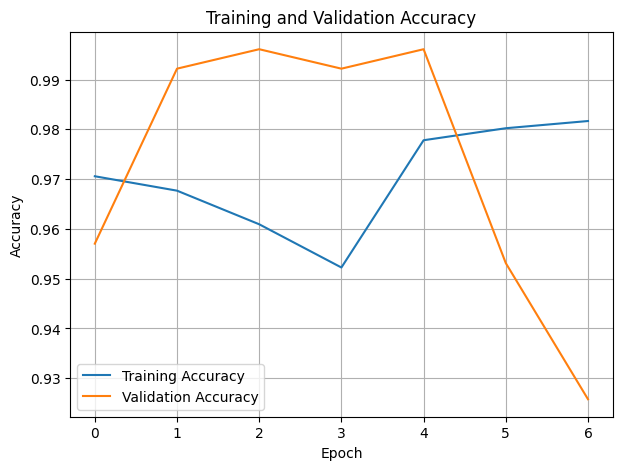

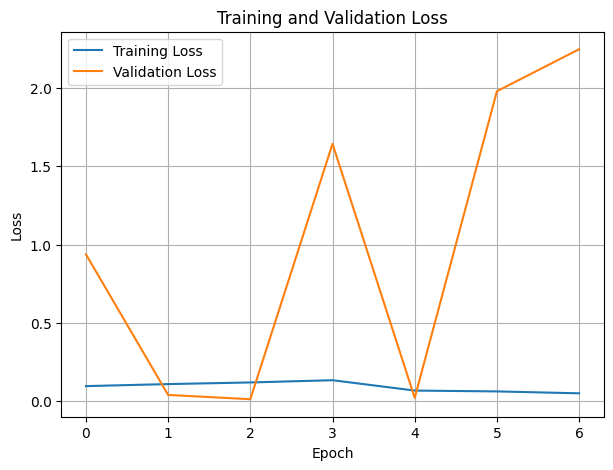

In [43]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(7, 5))
plt.plot(weighted_history.history["accuracy"], label="Training Accuracy")
plt.plot(weighted_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss
plt.figure(figsize=(7, 5))
plt.plot(weighted_history.history["loss"], label="Training Loss")
plt.plot(weighted_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [44]:
import pandas as pd

# Get training history as a table
history_data = pd.DataFrame({
    "Epoch": range(1, len(weighted_history.history["loss"]) + 1),
    "Training Accuracy": weighted_history.history["accuracy"],
    "Validation Accuracy": weighted_history.history["val_accuracy"],
    "Training Loss": weighted_history.history["loss"],
    "Validation Loss": weighted_history.history["val_loss"]
})

# Show values rounded to 4 decimal places
history_data = history_data.round(4)

display(history_data)

,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,0.9706,0.9570,0.0949,0.9377
1,2,0.9677,0.9922,0.1079,0.0386
2,3,0.9609,0.9961,0.1184,0.0111
3,4,0.9522,0.9922,0.1327,1.6440
4,5,0.9778,0.9961,0.0664,0.0198
5,6,0.9802,0.9531,0.0610,1.9803
6,7,0.9817,0.9258,0.0489,2.2490


In [45]:
# Take one image from the existing test dataset
for images, labels in test_ds.take(1):
    image = images[0]
    actual_label = int(labels[0].numpy())

# Predict
probability = float(best_model.predict(
    np.expand_dims(image.numpy(), axis=0),
    verbose=0
)[0][0])

threshold = 0.55

if probability >= threshold:
    predicted_class = "Healthy"
    confidence = probability
else:
    predicted_class = "Early_Blight"
    confidence = 1 - probability

actual_class = class_names[actual_label]

print("Actual Class:", actual_class)
print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence * 100, 2), "%")
print("Raw Probability:", round(probability, 4))

Actual Class: Early_Blight
Predicted Class: Early_Blight
Confidence: 100.0 %
Raw Probability: 0.0


/tmp/ipykernel_1675/4110749736.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_label = int(labels[0].numpy())


**Check the output of binary classes**

In [46]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Select an image from your computer
uploaded = files.upload()

image_path = next(iter(uploaded))

# Load and resize image
img = load_img(image_path, target_size=(128, 128))

# Convert image to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
probability = float(best_model.predict(img_array, verbose=0)[0][0])

# Final threshold selected during your testing
threshold = 0.55

if probability >= threshold:
    predicted_class = "Healthy"
    confidence = probability
else:
    predicted_class = "Early_Blight"
    confidence = 1 - probability

print("=" * 40)
print("       TOMATO LEAF PREDICTION")
print("=" * 40)
print("Image:", image_path)
print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence * 100, 2), "%")
print("Raw Probability:", round(probability, 4))
print("=" * 40)

Saving img_h_108.jpg to img_h_108.jpg
       TOMATO LEAF PREDICTION
Image: img_h_108.jpg
Predicted Class: Healthy
Confidence: 99.99 %
Raw Probability: 0.9999


In [47]:
print("Raw probability:", probability)
print("Threshold:", threshold)
print("Predicted:", predicted_class)

Raw probability: 0.9998902082443237
Threshold: 0.55
Predicted: Healthy


In [48]:
print("Model input:", best_model.input_shape)
print("Uploaded image shape:", img_array.shape)
print("Uploaded image range:", img_array.min(), "to", img_array.max())

print("\nTraining batch range:")

for images, labels in train_ds.take(1):
    print("Shape:", images.shape)
    print("Range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Model input: (None, 128, 128, 3)
Uploaded image shape: (1, 128, 128, 3)
Uploaded image range: 0.0 to 255.0

Training batch range:
Shape: (32, 128, 128, 3)
Range: 0.0 to 250.5


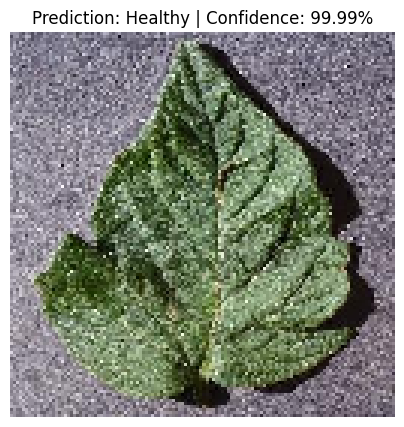

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class} | "
    f"Confidence: {confidence * 100:.2f}%"
)
plt.show()